# Dataset Validation

## Single Category

In [1]:
import json
from collections import Counter

splits = ["train", "val", "test"]

for split in splits:
    json_path = f"../.data/labels_coco/labels_coco_{split}.json"
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    categories = [img.get("doc_category") for img in data["images"]]
    
    dist = Counter(categories)
    
    print(f"\nDistribution in {split.upper()}-Split:")
    for cat, count in dist.items():
        print(f"  - {cat}: {count} Images")


Distribution in TRAIN-Split:
  - scientific_articles: 5000 Images

Distribution in VAL-Split:
  - scientific_articles: 944 Images

Distribution in TEST-Split:
  - scientific_articles: 943 Images


In [2]:
import json

splits = ["train", "val", "test"]

for split in splits:
    json_path = f"../.data_multi_cat/labels_coco_multi_cat/labels_coco_{split}.json"
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    annotated_image_ids = {ann['image_id'] for ann in data['annotations']}
    
    total_images = len(data['images'])
    empty_images_count = 0
    empty_per_cat = {}
    
    for img in data['images']:
        img_id = img['id']
        cat = img.get("doc_category")
        
        if img_id not in annotated_image_ids:
            empty_images_count += 1
            empty_per_cat[cat] = empty_per_cat.get(cat, 0) + 1
            
    print(f"\n--- Background Analysis for {split.upper()} ---")
    print(f"Total images in subset: {total_images}")
    print(f"Of which are pure background images (without boxes): {empty_images_count} ({empty_images_count/total_images*100:.1f}%)")
    if empty_images_count > 0:
        print(f"Empty pages per category: {empty_per_cat}")


--- Background Analysis for TRAIN ---
Total images in subset: 9000
Of which are pure background images (without boxes): 47 (0.5%)
Empty pages per category: {'financial_reports': 13, 'laws_and_regulations': 34}

--- Background Analysis for VAL ---
Total images in subset: 2832
Of which are pure background images (without boxes): 8 (0.3%)
Empty pages per category: {'financial_reports': 5, 'laws_and_regulations': 2, 'scientific_articles': 1}

--- Background Analysis for TEST ---
Total images in subset: 2352
Of which are pure background images (without boxes): 2 (0.1%)
Empty pages per category: {'laws_and_regulations': 1, 'financial_reports': 1}


Checking Image-ID: a5576aecc566fd26bb619b49a8959a27b1690f814f3f370779924fa70dfd9587.png (ID: 23218)
Document Category: scientific_articles
Image file found. Proceeding with annotation check...
13 Found annotations for this image.


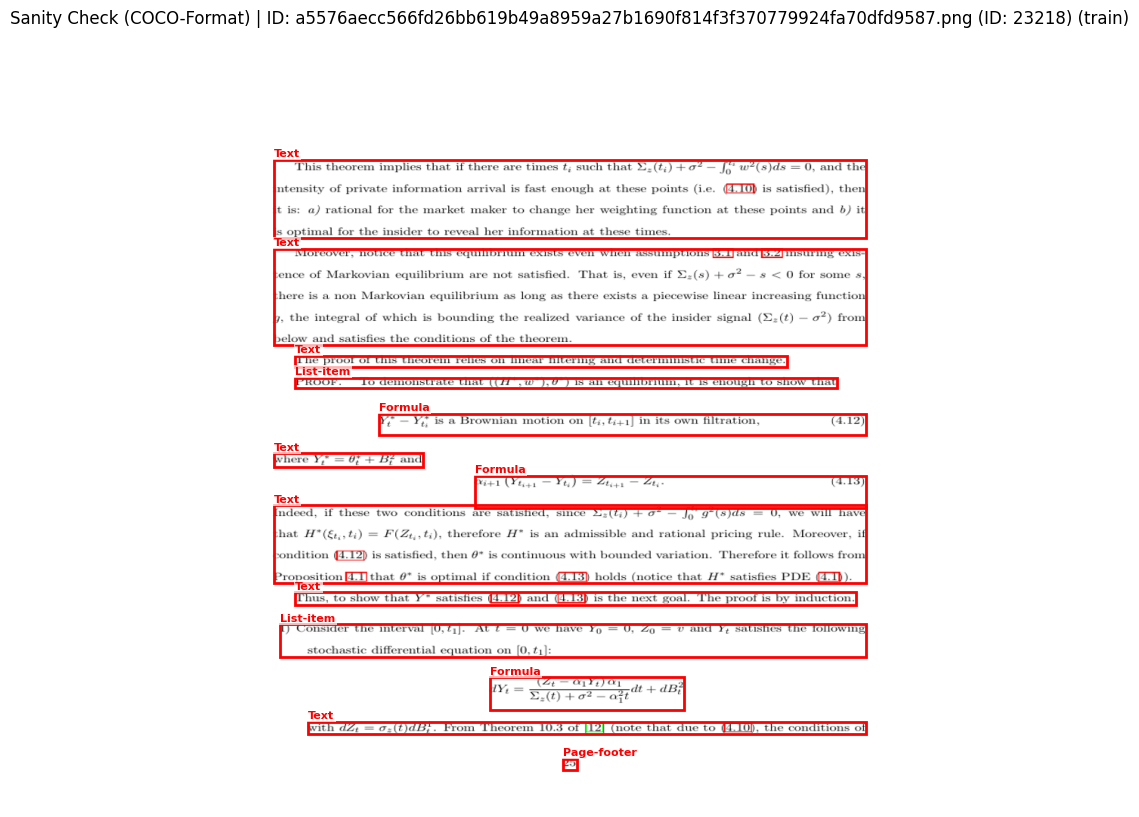

In [3]:
import json
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

SUBSET_DIR = "../.data"
SPLIT = "train"

JSON_PATH = f"{SUBSET_DIR}/labels_coco/labels_coco_{SPLIT}.json"
IMAGES_DIR = f"{SUBSET_DIR}/images/{SPLIT}"

with open(JSON_PATH, 'r') as f:
    coco_data = json.load(f)

cat_id_to_name = {c['id']: c['name'] for c in coco_data['categories']}

random_img_info = random.choice(coco_data['images'])
img_file_name = random_img_info['file_name']
img_path = os.path.join(IMAGES_DIR, img_file_name)

print(f"Checking Image-ID: {img_file_name} (ID: {random_img_info['id']})")
print(f"Document Category: {random_img_info.get('doc_category')}")

if not os.path.exists(img_path):
    print(f"ERROR: Image file {img_file_name} not found in folder {IMAGES_DIR}!")
    exit()
else:
    print("Image file found. Proceeding with annotation check...")

img_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == random_img_info['id']]
print(f"{len(img_annotations)} Found annotations for this image.")

img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img)

for ann in img_annotations:
    x, y, w, h = ann['bbox']
    cat_name = cat_id_to_name[ann['category_id']]

    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    plt.text(x, y - 4, cat_name, color='red', fontsize=8, weight='bold',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.title(f"Sanity Check (COCO-Format) | ID: {img_file_name} (ID: {random_img_info['id']}) ({SPLIT})")
plt.axis('off')

plt.show()